## Gamma-ray burst detection

In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np

from gridcp.calibration import calibrate_threshold_false_alarm_from_data
from gridcp.detector import GridDetector
from gridcp.scores import ExponentialFamilyGLR, NPFOCuS

grb_file = "../data-NPFOCuS/grb171004857.pickle"
data_dir = "../data-NPFOCuS"
grb_filename = "grb171004857.pickle"

with open(grb_file, "rb") as fh:
    t, counts_dict, trigger_t, trigger_str = pickle.load(fh)

t_mid = (t[:-1] + t[1:]) / 2
channels = list(counts_dict.keys())
grb_matrix = np.column_stack([counts_dict[c] for c in channels]).astype(np.float64)
grb_total = grb_matrix.sum(axis=1)

print(f"Trigger: {trigger_str}")
print(f"Bins: {len(t_mid)}, Channels: {channels}")

Trigger: 2017-10-04T20:33:35
Bins: 599, Channels: ['n8_r0', 'n8_r1', 'n8_r2', 'nb_r0', 'nb_r1', 'nb_r2']


## Plot the total counts across detectors

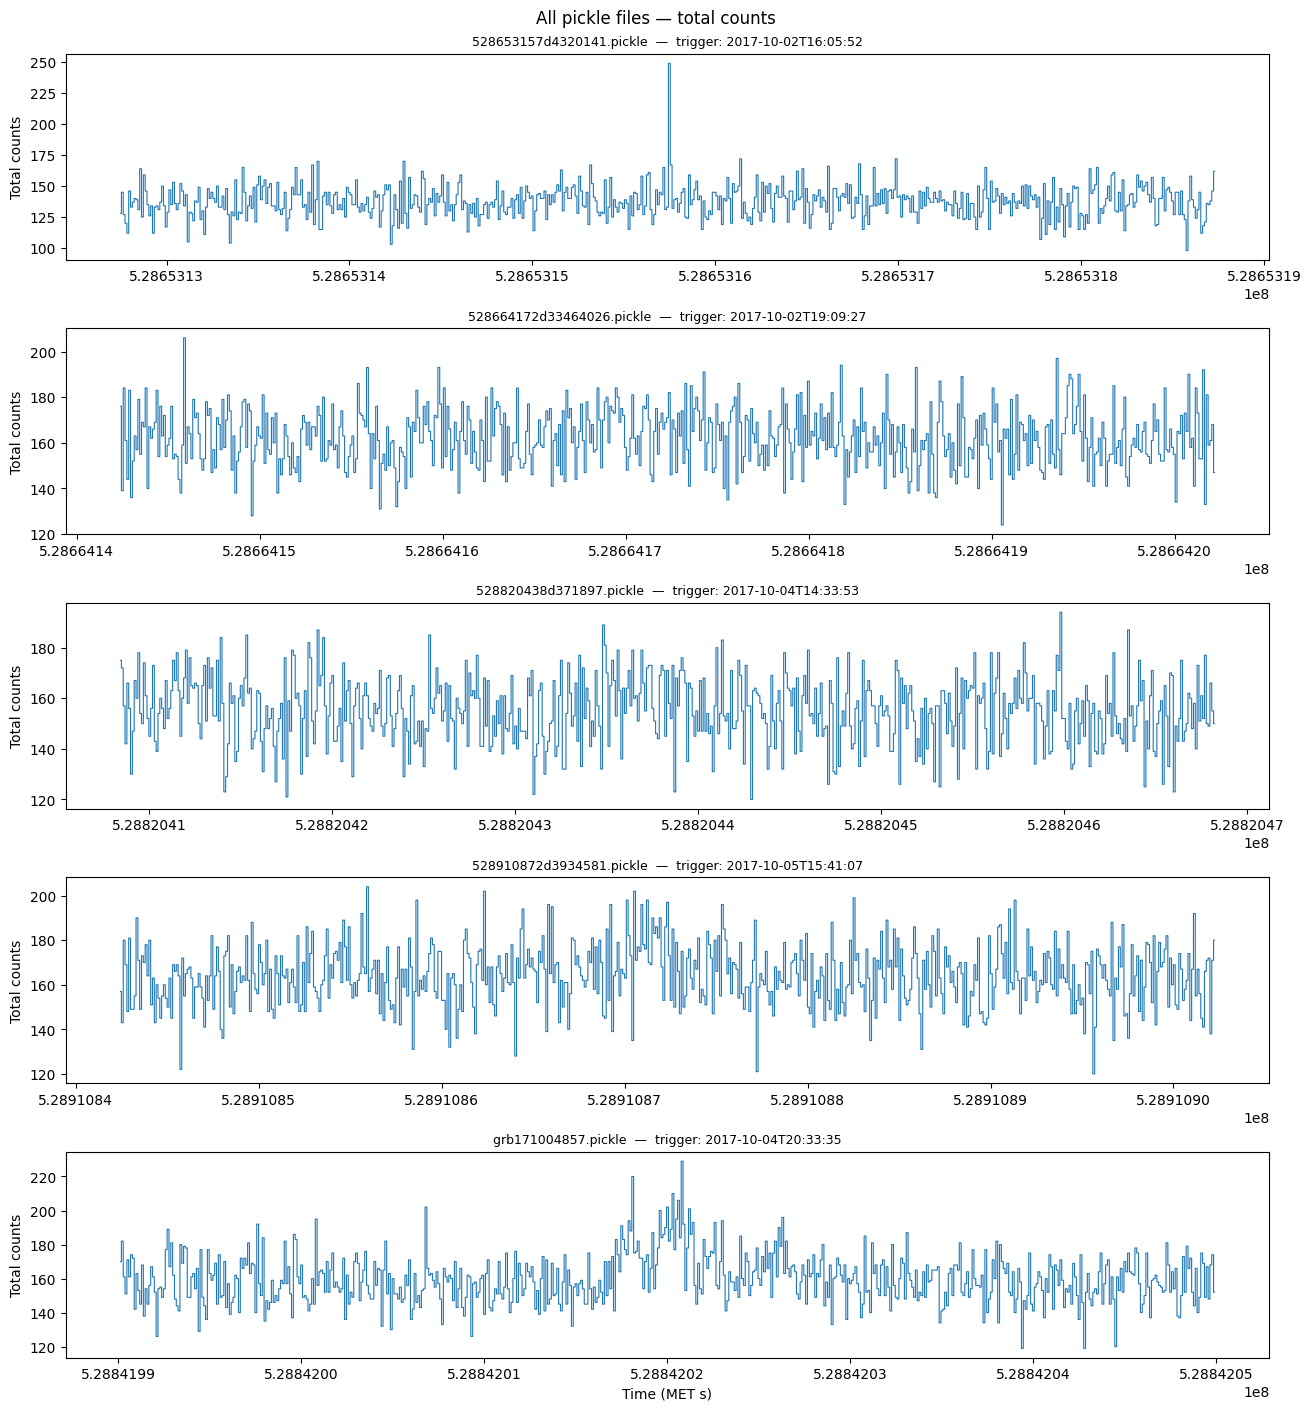

In [2]:
fig, axes = plt.subplots(5, 1, figsize=(13, 14), constrained_layout=True)

all_fnames = sorted(f for f in os.listdir(data_dir) if f.endswith(".pickle"))
for ax, fname in zip(axes, all_fnames):
    with open(os.path.join(data_dir, fname), "rb") as fh:
        t_f, counts_f, _, trigger_str_f = pickle.load(fh)
    t_mid_f = (t_f[:-1] + t_f[1:]) / 2
    total_f = np.column_stack(list(counts_f.values())).sum(axis=1)
    ax.step(t_mid_f, total_f, where="mid", linewidth=0.8)
    ax.set_title(f"{fname}  —  trigger: {trigger_str_f}", fontsize=9)
    ax.set_ylabel("Total counts")
    ax.ticklabel_format(useOffset=False, axis="x")

axes[-1].set_xlabel("Time (MET s)")
fig.suptitle("All pickle files — total counts", fontsize=12)
plt.show()

## Defining the score models and calibration

Thresholds are estimated by circular block bootstrapping (Politis & Romano, 1992) applied to pre-trigger background data. Each pickle file consists of a 60 s window centered on a Fermi/GBM trigger. The first 30 seconds (bins 0–298) are therefore pre-trigger and treated as change-free training data. The four files contribute 4 × 299 = 1196 bins of background noise.

In [24]:
trigger_bin = 299
target_fa = 0.1
n_paths = 10000
stream_len = len(grb_total)
n_jobs = 18 

bg_fnames = sorted(
    f for f in os.listdir(data_dir) if f.endswith(".pickle") and f != grb_filename
)

cal_chunks = []
for fname in bg_fnames:
    with open(os.path.join(data_dir, fname), "rb") as fh:
        _, counts_bg, _, _ = pickle.load(fh)
    mat = np.column_stack(list(counts_bg.values())).astype(np.float64)
    pre = mat[:trigger_bin]
    cal_chunks.append(pre.sum(axis=1, keepdims=True))

training_data = np.concatenate(cal_chunks, axis=0)

background_mean_est = training_data.mean()
background_sd_est = training_data.std()

poisson_theta_init = np.log(background_mean_est)

glr_score = ExponentialFamilyGLR.from_family(
    "poisson",
    n_features=1,
    theta_init=poisson_theta_init,
    enable_penalty=False,
)

value_grid = np.linspace(
    background_mean_est - background_sd_est * 2,
    background_mean_est + background_sd_est * 2,
).reshape(50)

npfocus_score_obj = NPFOCuS(
    value_grid=value_grid,
    n_features=1,
)

print("poisson_theta_init", poisson_theta_init)

glr_threshold = calibrate_threshold_false_alarm_from_data(
    glr_score,
    training_data,
    false_alarm_probability=target_fa,
    stream_len=stream_len,
    n_paths=n_paths,
    rng=0,
    n_jobs=n_jobs,
)

npfocus_threshold = calibrate_threshold_false_alarm_from_data(
    npfocus_score_obj,
    training_data,
    false_alarm_probability=target_fa,
    stream_len=stream_len,
    n_paths=n_paths,
    rng=0,
    n_jobs=n_jobs,
)

glr_det = GridDetector(
    score=glr_score,
    threshold=glr_threshold,
)
npf_det = GridDetector(
    score=npfocus_score_obj,
    threshold=npfocus_threshold,
)

print(f"Training: {len(training_data)} bins from {len(bg_fnames)} background files (pre-trigger only)")
print(f"Stream length: {stream_len}, false alarm prob: {target_fa}, n_paths: {n_paths}")
print(f"GLR threshold:     {glr_threshold}")
print(f"NPFOCuS threshold: {npfocus_threshold}")

poisson_theta_init 5.044045271977882
Training: 1196 bins from 4 background files (pre-trigger only)
Stream length: 599, false alarm prob: 0.1, n_paths: 10000
GLR threshold:     [90.49447721]
NPFOCuS threshold: [1210.60826357   59.65594375]


## Run Detectors

Both detectors run online on the total counts using the same simple loop used throughout the notebooks: call `detector.update` on each observation and reset state after every alarm.

In [25]:
glr_state = glr_det.init_state()
glr_trace = []
glr_alarms = []

npf_state = npf_det.init_state()
npf_trace = []
npf_alarms = []

for i, y in enumerate(grb_total):
    glr_state, glr_out = glr_det.update(glr_state, y)
    glr_trace.append(glr_out["max_score"].copy())
    if glr_out["alarm"]:
        glr_alarms.append(i)
        glr_state = glr_det.init_state()

    npf_state, npf_out = npf_det.update(npf_state, y)
    npf_trace.append(npf_out["max_score"].copy())
    if npf_out["alarm"]:
        npf_alarms.append(i)
        npf_state = npf_det.init_state()

glr_trace = np.stack(glr_trace)
npf_trace = np.stack(npf_trace)

print(f"GLR: detected {len(glr_alarms)} alarm(s). Alarm times: {glr_alarms}")
print(f"NPFOCuS: detected {len(npf_alarms)} alarm(s). Alarm times: {npf_alarms}")

GLR: detected 1 alarm(s). Alarm times: [304]
NPFOCuS: detected 1 alarm(s). Alarm times: [304]


## Plot Results

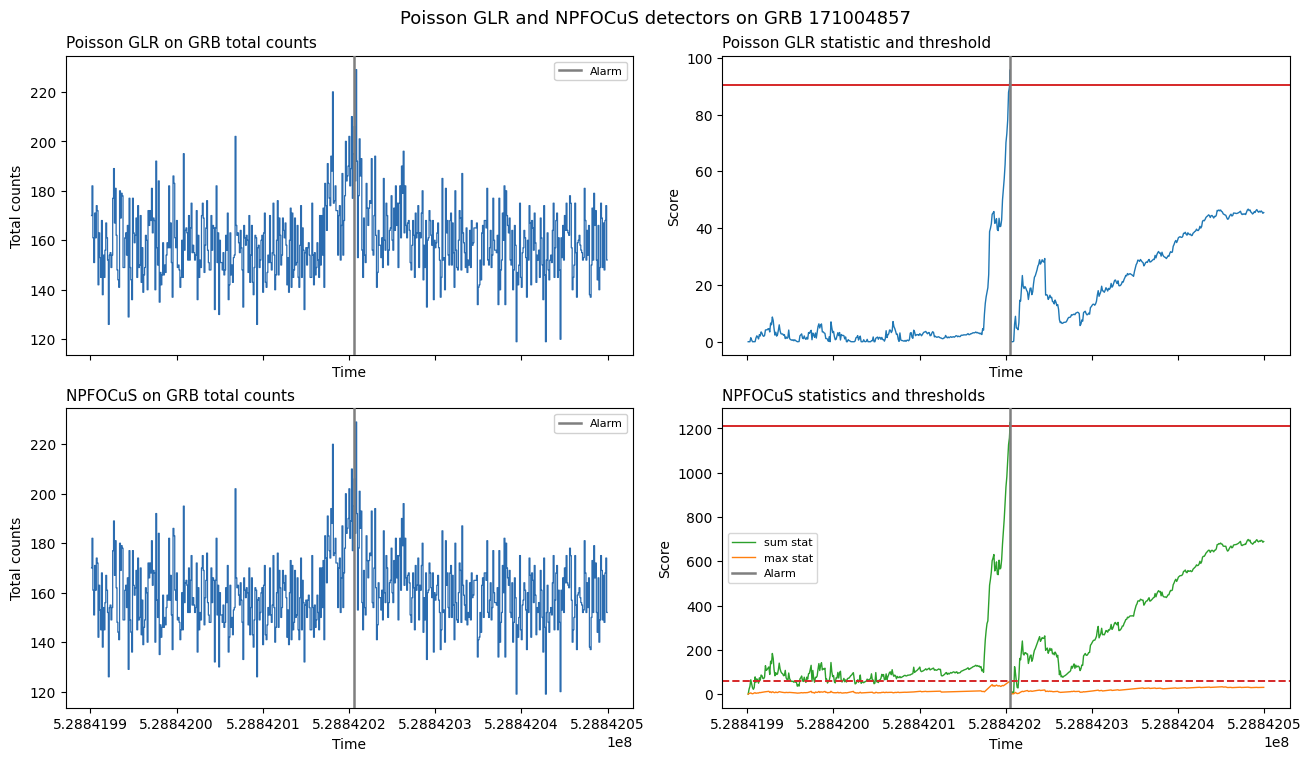

In [26]:
threshold_color = "#d62728"
score_color_glr = "#1f77b4"
score_color_npf_sum = "#2ca02c"
score_color_npf_max = "#ff7f0e"
alarm_color = "#7f7f7f"
count_color = "#2b6cb0"


def draw_alarm_lines(ax, alarm_indices):
    for idx, alarm_idx in enumerate(alarm_indices):
        ax.axvline(
            t_mid[alarm_idx],
            color=alarm_color,
            linewidth=1.8,
            label="Alarm" if idx == 0 else None,
            zorder=4,
        )


def draw_count_panel(ax, alarm_indices, title):
    ax.step(t_mid, grb_total, where="mid", color=count_color, linewidth=0.9)
    draw_alarm_lines(ax, alarm_indices)
    ax.set_ylabel("Total counts")
    ax.set_title(title, loc="left", fontsize=11)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, loc="upper right", fontsize=8, framealpha=0.9)


fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex="col", constrained_layout=True)

draw_count_panel(axes[0, 0], glr_alarms, "Poisson GLR on GRB total counts")
draw_count_panel(axes[1, 0], npf_alarms, "NPFOCuS on GRB total counts")

axes[0, 1].plot(t_mid, glr_trace[:, 0], color=score_color_glr, linewidth=1.0)
axes[0, 1].axhline(glr_threshold[0], color=threshold_color, linewidth=1.4)
draw_alarm_lines(axes[0, 1], glr_alarms)
axes[0, 1].set_ylabel("Score")
axes[0, 1].set_title("Poisson GLR statistic and threshold", loc="left", fontsize=11)

axes[1, 1].plot(t_mid, npf_trace[:, 0], color=score_color_npf_sum, linewidth=1.0, label="sum stat")
axes[1, 1].axhline(npfocus_threshold[0], color=threshold_color, linewidth=1.4)
axes[1, 1].plot(t_mid, npf_trace[:, 1], color=score_color_npf_max, linewidth=1.0, label="max stat")
axes[1, 1].axhline(npfocus_threshold[1], color=threshold_color, linestyle="--", linewidth=1.4)
draw_alarm_lines(axes[1, 1], npf_alarms)
axes[1, 1].legend(fontsize=8)
axes[1, 1].set_ylabel("Score")
axes[1, 1].set_title("NPFOCuS statistics and thresholds", loc="left", fontsize=11)

for ax in axes.flat:
    ax.ticklabel_format(useOffset=False, axis='x')
for ax in axes[:, 0]:
    ax.set_xlabel("Time")
for ax in axes[:, 1]:
    ax.set_xlabel("Time")

fig.suptitle("Poisson GLR and NPFOCuS detectors on GRB 171004857", fontsize=13)
fig.savefig("GRB_171004857_detection.pdf")
plt.show()